In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Projecte_Visio/TrashType_Image_Dataset"

In [ ]:
import os

print(os.listdir(DATASET_PATH))

['metal', 'plastic', 'paper', 'trash', 'glass', 'cardboard']


In [ ]:
# IMPORTS

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
# VEURE CLASSES

classes = sorted(os.listdir(DATASET_PATH))

print("Classes trobades:")
print(classes)

Classes trobades:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# COMPTAR IMATGES

counts = {}

for c in classes:
    class_path = os.path.join(DATASET_PATH, c)
    counts[c] = len(os.listdir(class_path))

print("\nNombre d'imatges per classe:")
print(counts)



Nombre d'imatges per classe:
{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


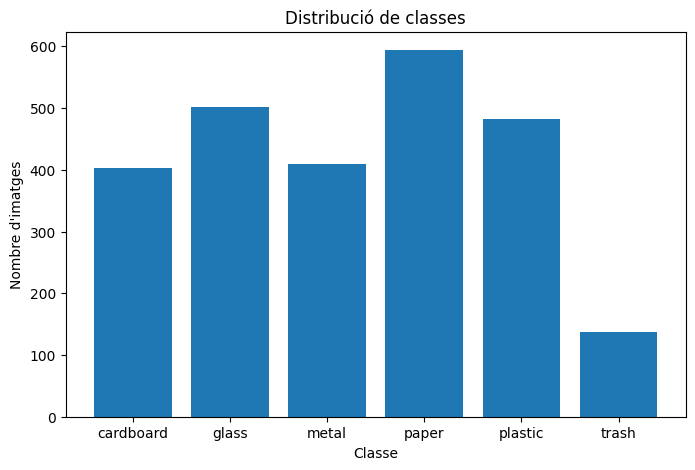

In [ ]:
# MOSTRAR DISTRIBUCIÓ

plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values())
plt.title("Distribució de classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'imatges")
plt.show()

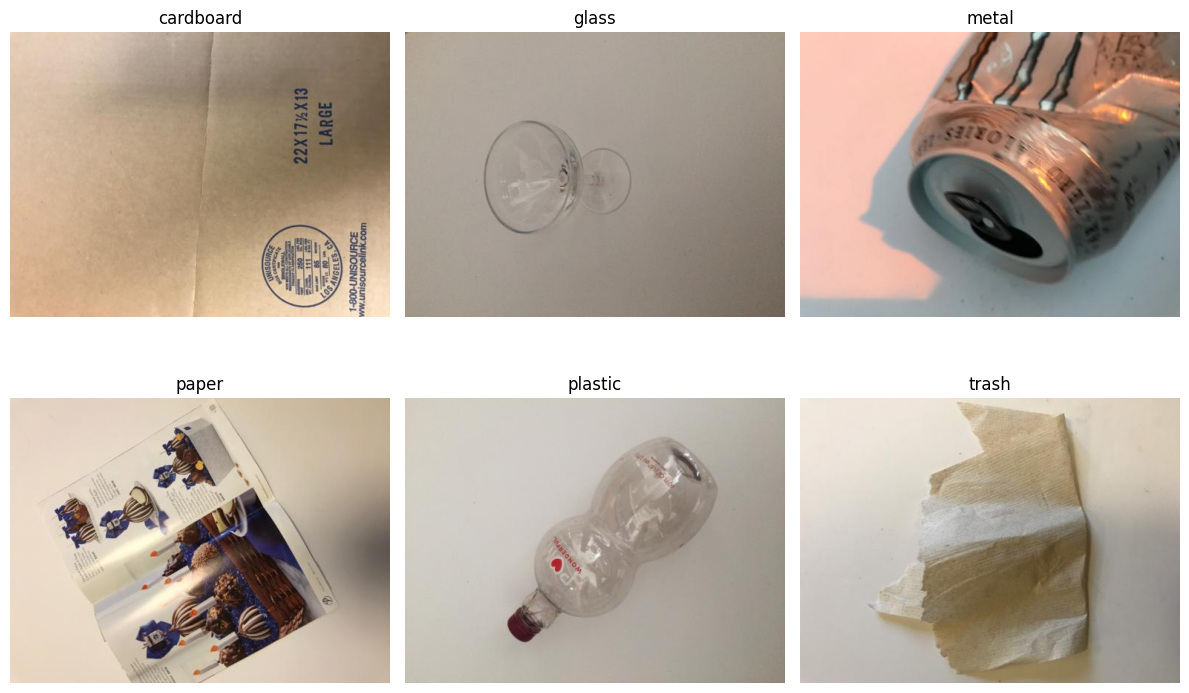

In [ ]:
# MOSTRAR EXEMPLES

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, c in zip(axes.flatten(), classes):
    class_path = os.path.join(DATASET_PATH, c)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# PREPARAR DADES

X = []
y = []
paths = []

IMG_SIZE = 128


In [ ]:
# EXTRAURE CARACTERÍSTIQUES HOG (Histogram of Oriented Gradients).

for label in classes:
    class_path = os.path.join(DATASET_PATH, label)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        # Llegir imatge en color (BGR)
        img_bgr = cv2.imread(img_path)
        img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))

        # Descriptor HOG (grayscale)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        hog_features = hog(
            img_gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        # Histograma de color HSV
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist(
            [img_hsv], [0, 1, 2], None,
            [8, 8, 8], [0, 180, 0, 256, 0, 256]
        )
        hist = cv2.normalize(hist, hist).flatten()

        # Concatenar descriptors
        features = np.concatenate([hog_features, hist])

        X.append(features)
        y.append(label)
        paths.append(img_path)

print("Extracció de característiques completada.")


Extracció de característiques completada.


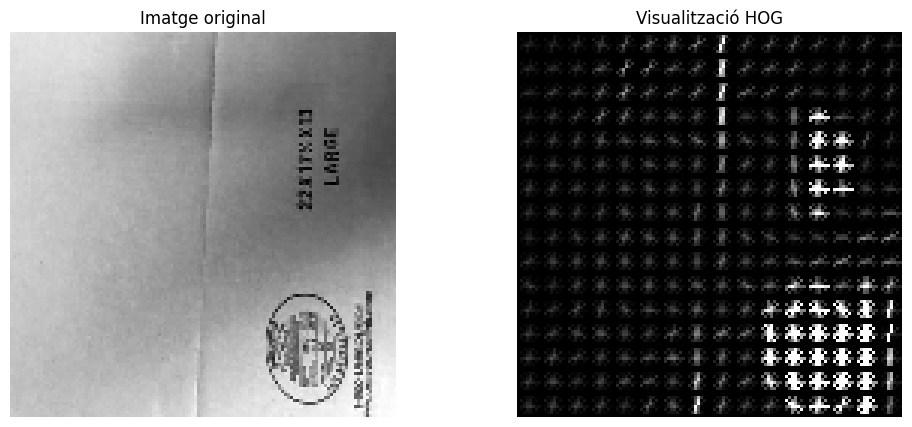

In [ ]:
#aquesta i la següent es per entrendre que fa hog, pero no calen

from skimage.feature import hog
from skimage import exposure

# EXEMPLE HOG

example_class = classes[0]

example_path = os.path.join(
    DATASET_PATH,
    example_class,
    os.listdir(os.path.join(DATASET_PATH, example_class))[0]
)

# Llegir imatge
img_bgr = cv2.imread(example_path)

# Resize
img_bgr = cv2.resize(img_bgr, (128, 128))

# Convertir a grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# HOG + visualització
features, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)

# Millorar contrast visual
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

# Mostrar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Imatge original")
axes[0].axis("off")

axes[1].imshow(hog_image_rescaled, cmap='gray')
axes[1].set_title("Visualització HOG")
axes[1].axis("off")

plt.show()

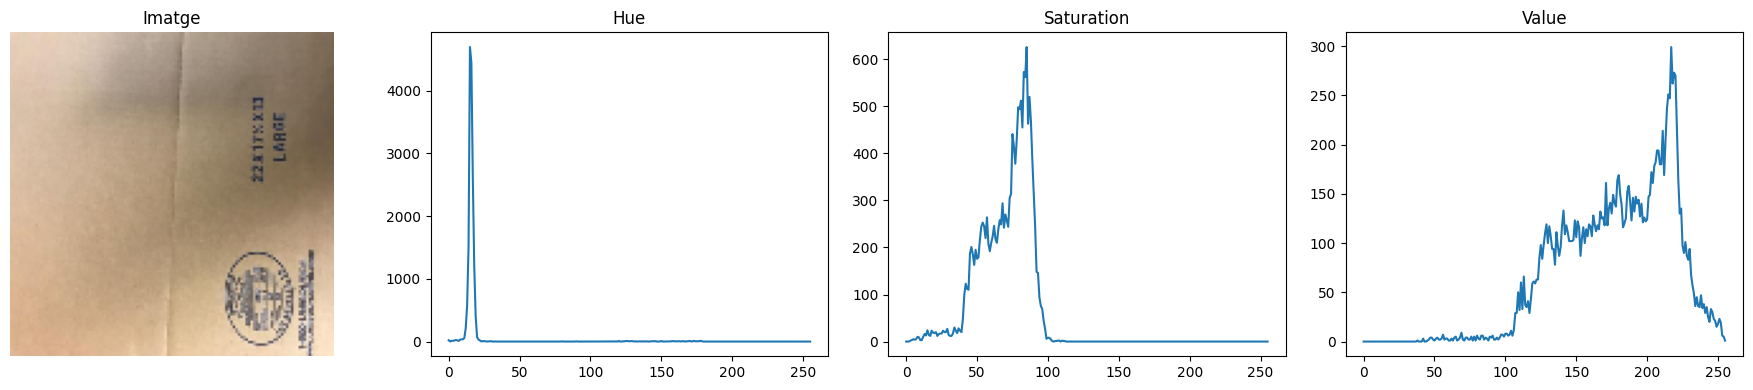

In [ ]:
# HISTOGRAMA HSV

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Histogrames
colors = ['Hue', 'Saturation', 'Value']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Imatge
axes[0].imshow(img_rgb)
axes[0].set_title("Imatge")
axes[0].axis("off")

# Histogrames
for i in range(3):

    hist = cv2.calcHist([img_hsv], [i], None, [256], [0, 256])

    axes[i+1].plot(hist)

    axes[i+1].set_title(colors[i])

plt.tight_layout()
plt.show()

In [ ]:
# CONVERTIR A NUMPY

X = np.array(X)
y = np.array(y)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)



Shape X: (2527, 8612)
Shape y: (2527,)


In [ ]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X,
    y,
    paths,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain samples:", len(X_train))
print("Test samples:", len(X_test))



Train samples: 2021
Test samples: 506


In [ ]:
# NORMALITZACIÓ (important per SVM i k-NN)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Normalització completada.")

Normalització completada.


## Cerca d'hiperparàmetres

In [ ]:
from sklearn.model_selection import GridSearchCV

# GRID SEARCH - SVM

svm_params = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']

}

svm_grid = GridSearchCV(
    SVC(class_weight='balanced'),
    svm_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid.fit(X_train_sc, y_train)

print("Millors paràmetres SVM:")
print(svm_grid.best_params_)

best_svm = svm_grid.best_estimator_

Millors paràmetres SVM:
{'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# GRID SEARCH - RANDOM FOREST

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Millors paràmetres RF:")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

Millors paràmetres RF:
{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}


In [ ]:
# GRID SEARCH - k-NN

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

knn_grid.fit(X_train_sc, y_train)

print("Millors paràmetres k-NN:")
print(knn_grid.best_params_)

best_knn = knn_grid.best_estimator_

Millors paràmetres k-NN:
{'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
# RESULTATS DELS TRES MODELS

models = {
    'SVM': (best_svm, X_test_sc),
    'Random Forest': (best_rf, X_test),
    'k-NN': (best_knn, X_test_sc)
}

preds = {}

for name, (model, X_eval) in models.items():
    p = model.predict(X_eval)
    preds[name] = p
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, p))



  SVM
              precision    recall  f1-score   support

   cardboard       0.82      0.73      0.77        81
       glass       0.63      0.78      0.70       100
       metal       0.66      0.49      0.56        82
       paper       0.75      0.87      0.81       119
     plastic       0.59      0.60      0.59        97
       trash       1.00      0.44      0.62        27

    accuracy                           0.69       506
   macro avg       0.74      0.65      0.67       506
weighted avg       0.70      0.69      0.69       506


  Random Forest
              precision    recall  f1-score   support

   cardboard       0.85      0.70      0.77        81
       glass       0.61      0.68      0.64       100
       metal       0.63      0.48      0.54        82
       paper       0.67      0.98      0.80       119
     plastic       0.71      0.59      0.64        97
       trash       1.00      0.37      0.54        27

    accuracy                           0.69       506

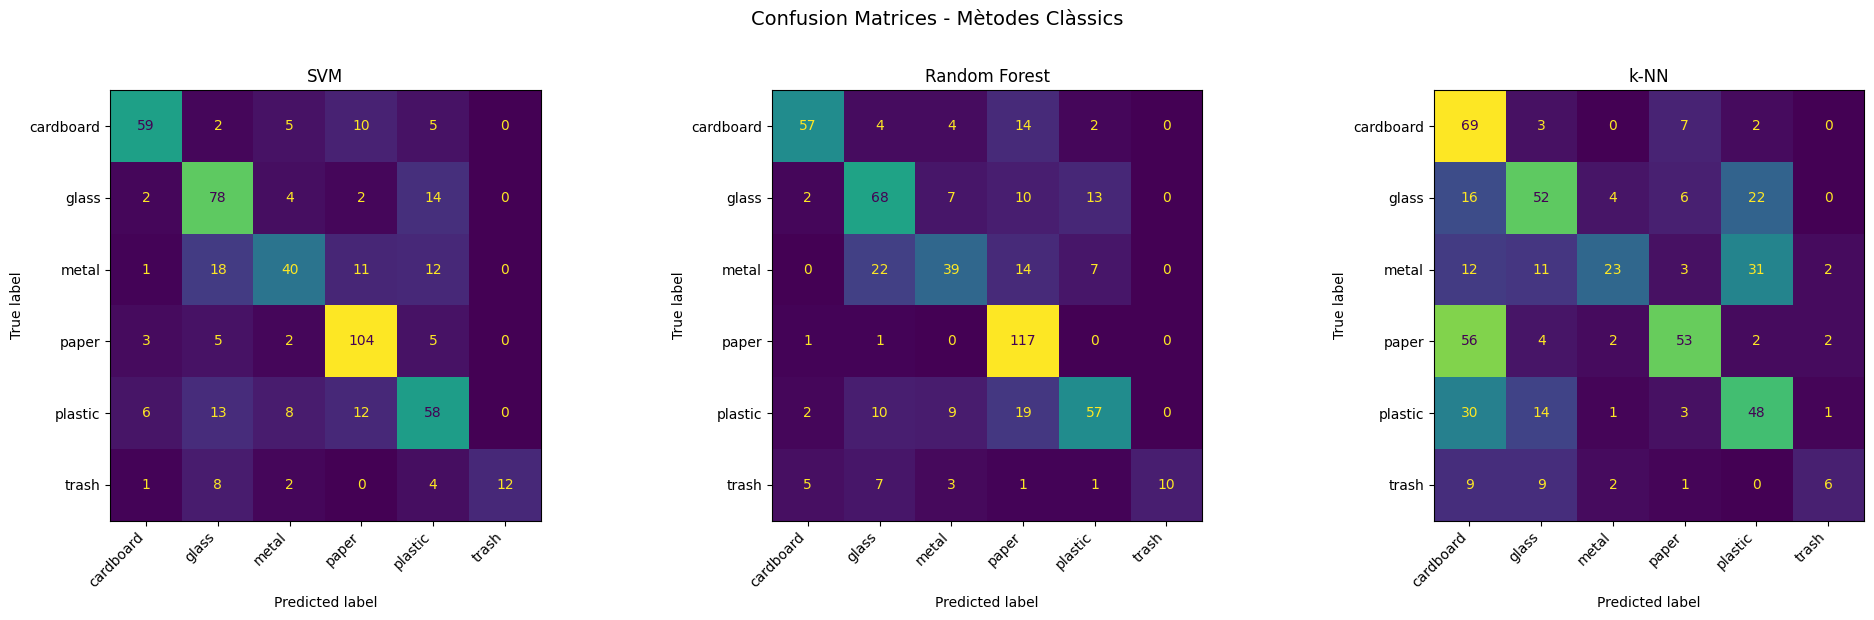

In [ ]:
# CONFUSION MATRICES

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, _) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds[name], labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle("Confusion Matrices - Mètodes Clàssics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Taula resultats agrupats

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, pred in preds.items():

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='macro'),
        'Recall': recall_score(y_test, pred, average='macro'),
        'F1-score': f1_score(y_test, pred, average='macro')
    })

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(by='F1-score',ascending=False)

results_df.reset_index(drop=True, inplace=True)

# print(results_df)

# display(results_df)

display(results_df.style.background_gradient(cmap='Blues'))


NameError: name 'preds' is not defined

In [ ]:
# Análisis de errores

# Prediccions del millor model
best_preds = best_svm.predict(X_test_sc)

# Índexs incorrectes
wrong_idx = np.where(best_preds != y_test)[0]

print(f"Errors totals: {len(wrong_idx)}")

Errors totals: 155


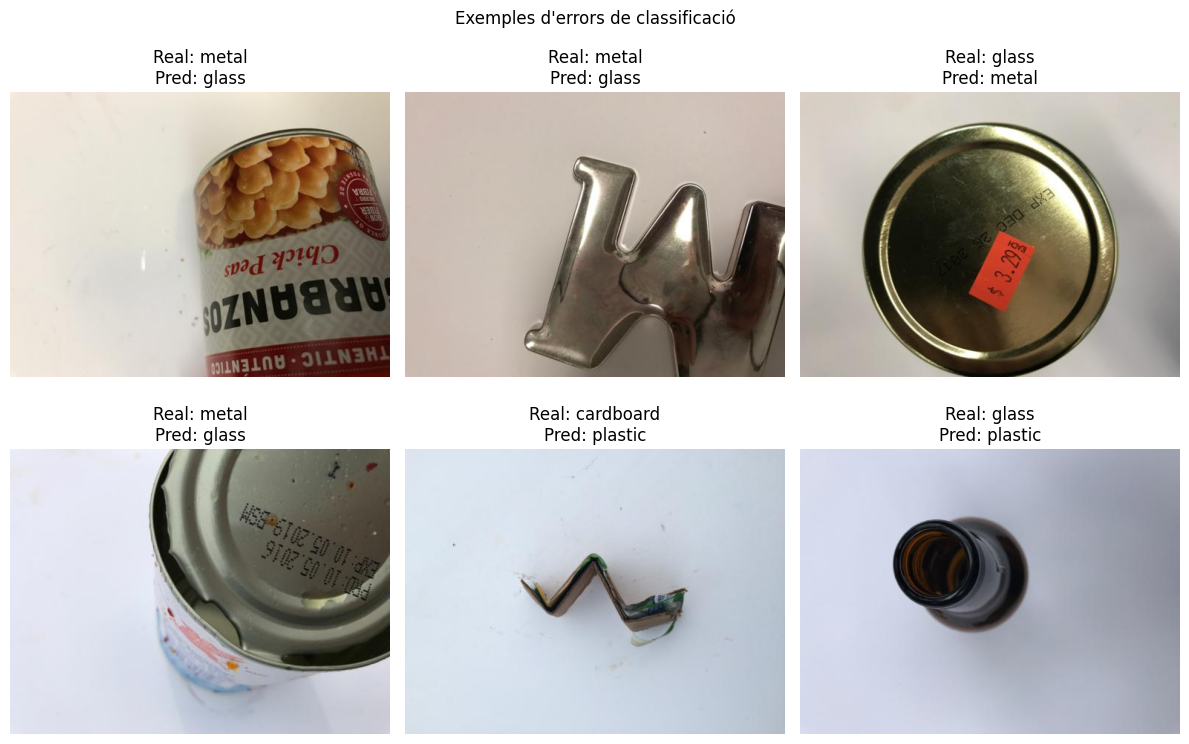

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

axes = axes.ravel()

for i, idx in enumerate(wrong_idx[:6]):

    img = plt.imread(test_paths[idx])

    axes[i].imshow(img)

    axes[i].set_title(
        f"Real: {y_test[idx]}\nPred: {best_preds[idx]}"
    )

    axes[i].axis("off")

plt.suptitle("Exemples d'errors de classificació")
plt.tight_layout()
plt.show()

In [ ]:
#repeteixo provant el lbp
#################################
# LBP + HSV + MODELS CLÀSSICS
#################################

from skimage.feature import local_binary_pattern

X_lbp = []
y_lbp = []

IMG_SIZE = 128

In [ ]:
# ======================
# EXTRACCIÓ LBP + HSV
# ======================

for label in classes:

    class_path = os.path.join(DATASET_PATH, label)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        # Llegir imatge
        img_bgr = cv2.imread(img_path)

        img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))

        # ======================
        # GRAYSCALE
        # ======================

        img_gray = cv2.cvtColor(
            img_bgr,
            cv2.COLOR_BGR2GRAY
        )

        # ======================
        # LBP
        # ======================

        radius = 1

        n_points = 8 * radius

        lbp = local_binary_pattern(
            img_gray,
            n_points,
            radius,
            method='uniform'
        )

        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, n_points + 3),
            range=(0, n_points + 2)
        )

        lbp_hist = lbp_hist.astype("float")

        lbp_hist /= (lbp_hist.sum() + 1e-6)

        # ======================
        # HSV HISTOGRAM
        # ======================

        img_hsv = cv2.cvtColor(
            img_bgr,
            cv2.COLOR_BGR2HSV
        )

        hist = cv2.calcHist(
            [img_hsv],
            [0, 1, 2],
            None,
            [8, 8, 8],
            [0, 180, 0, 256, 0, 256]
        )

        hist = cv2.normalize(hist, hist).flatten()

        # ======================
        # CONCATENAR
        # ======================

        features = np.concatenate([
            lbp_hist,
            hist
        ])

        X_lbp.append(features)

        y_lbp.append(label)

# ======================
# NUMPY
# ======================

X_lbp = np.array(X_lbp)

y_lbp = np.array(y_lbp)

print("Shape X_lbp:", X_lbp.shape)

print("Shape y_lbp:", y_lbp.shape)

Shape X_lbp: (2527, 522)
Shape y_lbp: (2527,)


In [ ]:
# ======================
# TRAIN TEST SPLIT
# ======================

X_train_lbp, X_test_lbp, y_train_lbp, y_test_lbp = train_test_split(
    X_lbp,
    y_lbp,
    test_size=0.2,
    stratify=y_lbp,
    random_state=42
)

print("\nTrain samples:", len(X_train_lbp))

print("Test samples:", len(X_test_lbp))


Train samples: 2021
Test samples: 506


In [ ]:
# ======================
# NORMALITZACIÓ
# ======================

scaler_lbp = StandardScaler()

X_train_lbp_sc = scaler_lbp.fit_transform(X_train_lbp)

X_test_lbp_sc = scaler_lbp.transform(X_test_lbp)

print("Normalització LBP + HSV completada.")

#################################
# GRID SEARCH - SVM
#################################

svm_grid_lbp = GridSearchCV(
    SVC(class_weight='balanced'),
    svm_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid_lbp.fit(
    X_train_lbp_sc,
    y_train_lbp
)

print("\nMillors paràmetres SVM LBP + HSV:")

print(svm_grid_lbp.best_params_)

best_svm_lbp = svm_grid_lbp.best_estimator_

#################################
# GRID SEARCH - RANDOM FOREST
#################################

rf_grid_lbp = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    rf_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid_lbp.fit(
    X_train_lbp,
    y_train_lbp
)

print("\nMillors paràmetres RF LBP + HSV:")

print(rf_grid_lbp.best_params_)

best_rf_lbp = rf_grid_lbp.best_estimator_

#################################
# GRID SEARCH - kNN
#################################

knn_grid_lbp = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

knn_grid_lbp.fit(
    X_train_lbp_sc,
    y_train_lbp
)

print("\nMillors paràmetres kNN LBP + HSV:")

print(knn_grid_lbp.best_params_)

best_knn_lbp = knn_grid_lbp.best_estimator_


Normalització LBP + HSV completada.


NameError: name 'GridSearchCV' is not defined

In [ ]:
#################################
# RESULTATS
#################################

models_lbp = {
    'SVM LBP+HSV': (
        best_svm_lbp,
        X_test_lbp_sc
    ),

    'Random Forest LBP+HSV': (
        best_rf_lbp,
        X_test_lbp
    ),

    'k-NN LBP+HSV': (
        best_knn_lbp,
        X_test_lbp_sc
    )
}

preds_lbp = {}

for name, (model, X_eval) in models_lbp.items():

    p = model.predict(X_eval)

    preds_lbp[name] = p

    print(f"\n{'='*40}")

    print(f"  {name}")

    print('='*40)

    print(classification_report(
        y_test_lbp,
        p
    ))

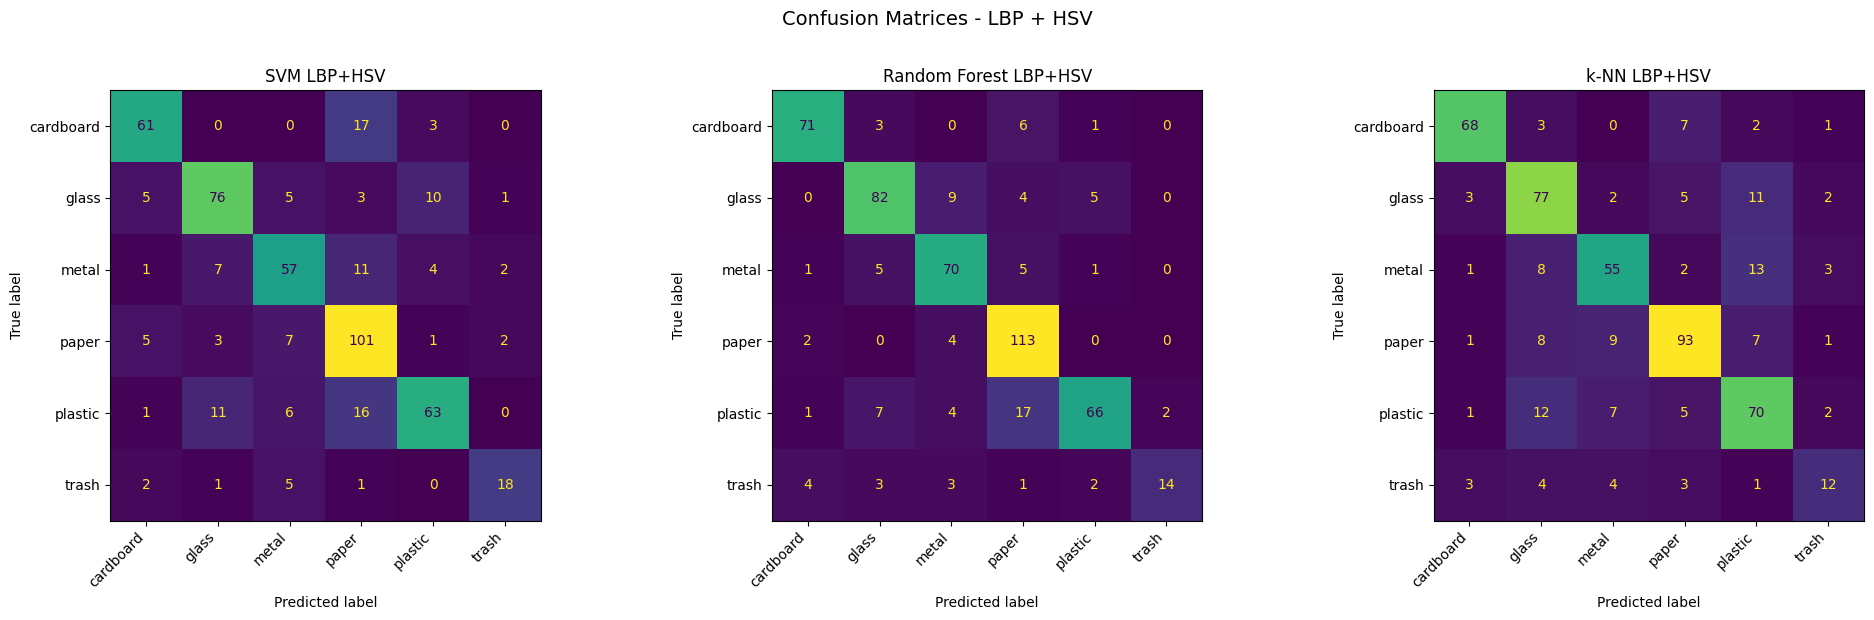

In [ ]:
#################################
# CONFUSION MATRICES
#################################

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

for ax, (name, _) in zip(
    axes,
    models_lbp.items()
):

    cm = confusion_matrix(
        y_test_lbp,
        preds_lbp[name],
        labels=classes
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha='right'
    )

plt.suptitle(
    "Confusion Matrices - LBP + HSV",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.show()

In [ ]:
#################################
# TAULA RESULTATS
#################################

results_lbp = []

for name, pred in preds_lbp.items():

    results_lbp.append({

        'Model': name,

        'Accuracy': accuracy_score(
            y_test_lbp,
            pred
        ),

        'Precision': precision_score(
            y_test_lbp,
            pred,
            average='macro'
        ),

        'Recall': recall_score(
            y_test_lbp,
            pred,
            average='macro'
        ),

        'F1-score': f1_score(
            y_test_lbp,
            pred,
            average='macro'
        )
    })

results_lbp_df = pd.DataFrame(
    results_lbp
)

results_lbp_df = results_lbp_df.round(4)

results_lbp_df = results_lbp_df.sort_values(
    by='F1-score',
    ascending=False
)

results_lbp_df.reset_index(
    drop=True,
    inplace=True
)

display(
    results_lbp_df.style.background_gradient(
        cmap='Greens'
    )
)

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest LBP+HSV,0.822100,0.837600,0.783100,0.798800
1,SVM LBP+HSV,0.743100,0.756600,0.728800,0.739200
2,k-NN LBP+HSV,0.741100,0.723000,0.704600,0.711700


In [ ]:
###############
# CNN
###############

# imports

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator


images = []
labels = []

In [ ]:
# imágenes

for label in classes:

    class_path = os.path.join(DATASET_PATH, label)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (128, 128))

        images.append(img)

        labels.append(label)

In [ ]:
X_img = np.array(images, dtype="float32") / 255.0
y_img = np.array(labels)

In [ ]:
le = LabelEncoder()

y_encoded = le.fit_transform(y_img)

y_cat = to_categorical(y_encoded)

In [ ]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img,
    y_cat,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [ ]:
# Del train traiem validació
X_train_final, X_val_img, y_train_final, y_val_img = train_test_split(
    X_train_img, y_train_img,
    test_size=0.2,
    stratify=np.argmax(y_train_img, axis=1),
    random_state=42
)

In [ ]:
#aixo ho posaria-ho o no? si ho posem s'ha de canviar el fit
# Data Augmentation (només sobre train)
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True
)
datagen.fit(X_train_final)

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(6, activation='softmax')
])

"""#al final he deixat la de sempre pq això em donava fatal nss pq
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(6, activation='softmax')
])"""

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


"#al final he deixat la de sempre pq això em donava fatal nss pq\nmodel = Sequential([\n\n    Conv2D(\n        32,\n        (3,3),\n        activation='relu',\n        input_shape=(128,128,3)\n    ),\n\n    BatchNormalization(),\n\n    MaxPooling2D(2,2),\n\n    Conv2D(\n        64,\n        (3,3),\n        activation='relu'\n    ),\n\n    BatchNormalization(),\n\n    MaxPooling2D(2,2),\n\n    Conv2D(\n        128,\n        (3,3),\n        activation='relu'\n    ),\n\n    BatchNormalization(),\n\n    MaxPooling2D(2,2),\n\n    Flatten(),\n\n    Dense(128, activation='relu'),\n\n    Dropout(0.5),\n\n    Dense(6, activation='softmax')\n])"

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [ ]:
# fit amb datagen i validació manual
history = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=32),
    validation_data=(X_val_img, y_val_img),
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 242ms/step - accuracy: 0.2457 - loss: 1.7454 - val_accuracy: 0.3259 - val_loss: 1.5403
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.3589 - loss: 1.5317 - val_accuracy: 0.4469 - val_loss: 1.3699
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.4307 - loss: 1.3837 - val_accuracy: 0.4444 - val_loss: 1.3786
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.4437 - loss: 1.3819 - val_accuracy: 0.4173 - val_loss: 1.3742
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.4425 - loss: 1.3636 - val_accuracy: 0.5086 - val_loss: 1.2254
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.5062 - loss: 1.3007 - val_accuracy: 0.4938 - val_loss: 1.2999
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.4969 - loss: 1.2775 - val_accuracy: 0.5407 - val_loss: 1.2990
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.5192 - loss: 1.2101 - val_accuracy: 0

In [ ]:
loss, acc = model.evaluate(X_test_img, y_test_img)

print(f"Accuracy CNN: {acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6976 - loss: 0.8726
Accuracy CNN: 0.6976


In [ ]:
pred_probs = model.predict(X_test_img)

preds_cnn = np.argmax(pred_probs, axis=1)

y_true = np.argmax(y_test_img, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [ ]:
print(classification_report(
    y_true,
    preds_cnn,
    target_names=le.classes_
))

              precision    recall  f1-score   support

   cardboard       0.85      0.86      0.86        81
       glass       0.61      0.67      0.64       100
       metal       0.59      0.77      0.67        82
       paper       0.80      0.77      0.79       119
     plastic       0.67      0.47      0.55        97
       trash       0.62      0.56      0.59        27

    accuracy                           0.70       506
   macro avg       0.69      0.68      0.68       506
weighted avg       0.70      0.70      0.69       506



In [ ]:


cnn_accuracy = accuracy_score(y_true, preds_cnn)
cnn_precision = precision_score(y_true,preds_cnn,average='macro')
cnn_recall = recall_score(y_true,preds_cnn,average='macro')
cnn_f1 = f1_score(y_true,preds_cnn,average='macro')

print("Accuracy :", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall   :", cnn_recall)
print("F1-score :", cnn_f1)

Accuracy : 0.6976284584980237
Precision: 0.6914648581772621
Recall   : 0.6842303028612955
F1-score : 0.6825812742432172


In [ ]:
"""
results = pd.DataFrame({
    'Model': ['SVM','Random Forest','k-NN','CNN'],
    'Accuracy': [svm_acc,rf_acc,knn_acc,cnn_accuracy],
    'Precision': [svm_precision,rf_precision,knn_precision,cnn_precision],
    'Recall': [svm_recall,rf_recall,knn_recall,cnn_recall],
    'F1-score': [svm_f1,rf_f1,knn_f1,cnn_f1]
})

results
"""

# CNN
results.append({
    'Model': 'CNN',
    'Accuracy': accuracy_score(y_true, preds_cnn),
    'Precision': precision_score(y_true, preds_cnn, average='macro'),
    'Recall': recall_score(y_true, preds_cnn, average='macro'),
    'F1-score': f1_score(y_true, preds_cnn, average='macro')
})

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

display(results_df.style.background_gradient(cmap='Blues'))

,Model,Accuracy,Precision,Recall,F1-score
0,CNN,0.697600,0.691500,0.684200,0.682600
1,SVM,0.693700,0.740700,0.652100,0.673900
2,Random Forest,0.687700,0.744700,0.633400,0.655700
3,k-NN,0.496000,0.561000,0.469100,0.465200


Vemos resultados incluso peores con la CNN, esto puede ser porque es la arquitectura es demasiado simple, también porque el dataset es pequeño y la CNN tarda en ejecutarse desde cero y rinde peor.

Podemos probar técnicas de transfer learning, MobileNetV2 o ResNet50

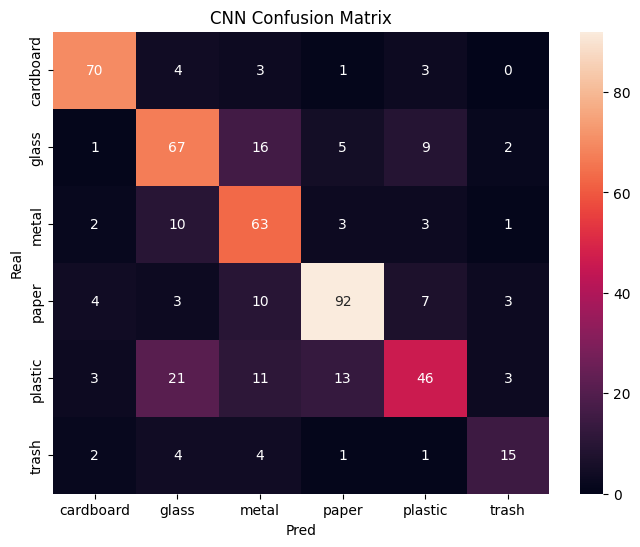

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, preds_cnn)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Pred")
plt.ylabel("Real")
plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.3)(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_img,
    y_train_img,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
  callbacks=[early_stop]
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9629 - loss: 0.1961 - val_accuracy: 0.8000 - val_loss: 0.5864
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9641 - loss: 0.1685 - val_accuracy: 0.7926 - val_loss: 0.5809
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9684 - loss: 0.1519 - val_accuracy: 0.7975 - val_loss: 0.5708
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9728 - loss: 0.1494 - val_accuracy: 0.8025 - val_loss: 0.5580
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9684 - loss: 0.1504 - val_accuracy: 0.7975 - val_loss: 0.5496
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9697 - loss: 0.1372 - val_accuracy: 0.8000 - val_loss: 0.5481
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9783 - loss: 0.1314 - val_accuracy: 0.8000 - val_loss: 0.5323
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9752 - loss: 0.1280 - val_accuracy: 0.8025 - v

In [ ]:
loss, acc = model.evaluate(X_test_img, y_test_img)

print(f"Accuracy MobileNetV2: {acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8241 - loss: 0.5675
Accuracy MobileNetV2: 0.8241


In [ ]:
pred_probs = model.predict(X_test_img)

preds_mobilenet = np.argmax(pred_probs, axis=1)

y_true = np.argmax(y_test_img, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    preds_mobilenet,
    target_names=le.classes_
))

              precision    recall  f1-score   support

   cardboard       0.96      0.85      0.90        81
       glass       0.82      0.77      0.79       100
       metal       0.82      0.79      0.81        82
       paper       0.81      0.96      0.88       119
     plastic       0.78      0.82      0.80        97
       trash       0.67      0.44      0.53        27

    accuracy                           0.82       506
   macro avg       0.81      0.77      0.79       506
weighted avg       0.82      0.82      0.82       506



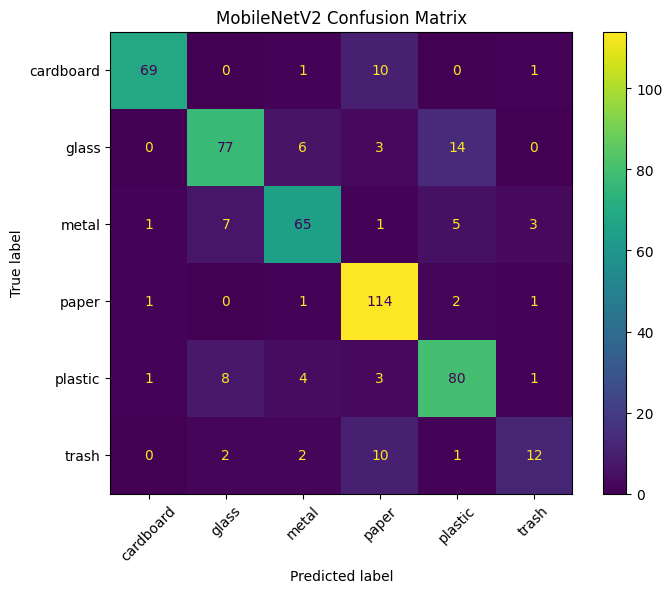

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, preds_mobilenet)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(ax=ax)

plt.xticks(rotation=45)

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [ ]:
# CNN

results = []

results.append({
    'Model': 'CNN',
    'Accuracy': accuracy_score(y_true, preds_cnn),
    'Precision': precision_score(y_true, preds_cnn, average='macro'),
    'Recall': recall_score(y_true, preds_cnn, average='macro'),
    'F1-score': f1_score(y_true, preds_cnn, average='macro')
})

results.append({
    'Model': 'MobileNetV2',
    'Accuracy': accuracy_score(y_true, preds_mobilenet),
    'Precision': precision_score(y_true, preds_mobilenet, average='macro'),
    'Recall': recall_score(y_true, preds_mobilenet, average='macro'),
    'F1-score': f1_score(y_true, preds_mobilenet, average='macro')
})

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

display(results_df.style.background_gradient(cmap='Blues'))

NameError: name 'preds_cnn' is not defined

In [ ]:
########################################
# FINE TUNING PARCIAL
########################################

# Descongelar MobileNet
base_model.trainable = True

# Congelar totes menys les últimes 30 capes
for layer in base_model.layers[:-30]:

    layer.trainable = False

########################################
# RECOMPILE AMB LR PETIT
########################################

from tensorflow.keras.optimizers import Adam

model.compile(

    optimizer=Adam(1e-5),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

########################################
# CONTINUAR ENTRENANT
########################################

history_finetune = model.fit(

    X_train_img,
    y_train_img,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 807ms/step - accuracy: 0.1894 - loss: 2.1491 - val_accuracy: 0.2642 - val_loss: 1.8558
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3292 - loss: 1.7046 - val_accuracy: 0.3951 - val_loss: 1.6036
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4400 - loss: 1.4608 - val_accuracy: 0.4593 - val_loss: 1.4287
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5309 - loss: 1.2544 - val_accuracy: 0.4988 - val_loss: 1.3044
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5823 - loss: 1.1131 - val_accuracy: 0.5506 - val_loss: 1.2108
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6454 - loss: 0.9892 - val_accuracy: 0.5852 - val_loss: 1.1420
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6844 - loss: 0.8811 - val_accuracy: 0.6025 - val_loss: 1.0867
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7252 - loss: 0.8173 - val_accuracy: 0.6148 -

# QUE opineu del early_Stop pq para molt aviat, no???? que es pq es queda amb 0.77 pero nss!!!!


In [ ]:
########################################
# RESULTATS FINE-TUNING
########################################

loss, acc = model.evaluate(
    X_test_img,
    y_test_img
)

print(f"Accuracy Fine-Tuning: {acc:.4f}")

pred_probs_ft = model.predict(X_test_img)

preds_ft = np.argmax(
    pred_probs_ft,
    axis=1
)

########################################
# METRIQUES
########################################

ft_accuracy = accuracy_score(
    y_true,
    preds_ft
)

ft_precision = precision_score(
    y_true,
    preds_ft,
    average='macro'
)

ft_recall = recall_score(
    y_true,
    preds_ft,
    average='macro'
)

ft_f1 = f1_score(
    y_true,
    preds_ft,
    average='macro'
)

print("Accuracy :", ft_accuracy)
print("Precision:", ft_precision)
print("Recall   :", ft_recall)
print("F1-score :", ft_f1)




16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8241 - loss: 0.5675
Accuracy Fine-Tuning: 0.8241
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy : 0.8241106719367589
Precision: 0.8099596850141441
Recall   : 0.7736174474073522
F1-score : 0.7862508573685679


In [ ]:
########################################
# AFEGIR A TAULA
########################################

results.append({
    'Model': 'MobileNetV2 Fine-Tuning',
    'Accuracy': ft_accuracy,
    'Precision': ft_precision,
    'Recall': ft_recall,
    'F1-score': ft_f1
})

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

display(
    results_df.style.background_gradient(
        cmap='Blues'
    )
)


,Model,Accuracy,Precision,Recall,F1-score
0,MobileNetV2 Fine-Tuning,0.824100,0.810000,0.773600,0.786300


Veiem que dona bastant baix i que, en descongelar més capes de MobileNetV2, els resultats encara baixen una mica més. Això pot ser perquè hi ha poques dades disponibles i el model necessita més varietat d’imatges per aprofitar millor el fine-tuning. Per aquest motiu, es podria provar \textit{data augmentation} per generar noves variants artificials de les imatges i intentar obtenir un millor F1-macro. Adalt està comentat pq ja ho vaig intentar, però els resultats no van ser gaire bons, possiblement perquè l’augmentació aplicada era massa simple??? O nss la vrt, pq encara que m'ho ha escrit el xat, la idea es meva i potser no cal fer-ho per millorar resultats i cal fer alguna altra cosa.jajjajaj



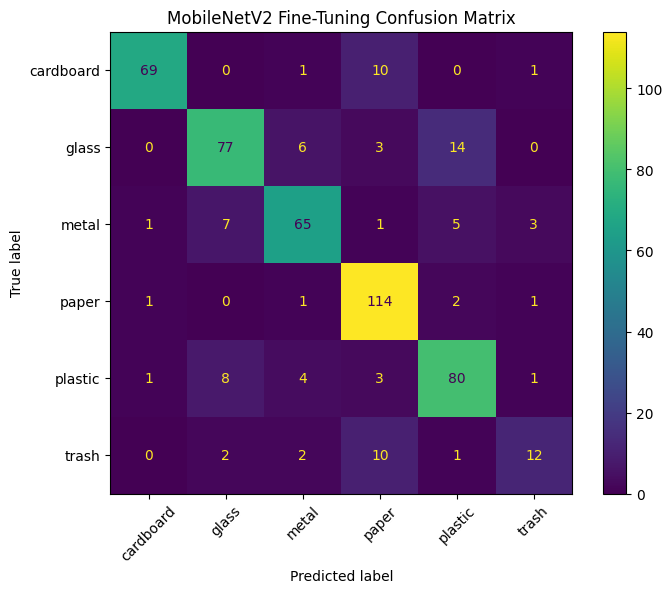

In [ ]:
########################################
# CONFUSION MATRIX
########################################

cm = confusion_matrix(
    y_true,
    preds_ft
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(ax=ax)

plt.xticks(rotation=45)

plt.title("MobileNetV2 Fine-Tuning Confusion Matrix")

plt.show()

In [ ]:
#################################################
# MOBILENETV2 FINE-TUNING (DESCONGELANT CAPES)
#################################################

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# DATA AUGMENTATION

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_img)

# BASE MODEL

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# DESCONGELAR ÚLTIMES 30 CAPES

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# MODEL

mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(6, activation='softmax')
])

# COMPILAR

mobilenet_model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# EARLY STOPPING

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ENTRENAMENT

history = mobilenet_model.fit(
    datagen.flow(X_train_img, y_train_img, batch_size=32),
    validation_data=(X_test_img, y_test_img),
    epochs=150,
    callbacks=[early_stop]
)

# EVALUACIÓ

loss, acc = mobilenet_model.evaluate(X_test_img, y_test_img)

print(f"Accuracy MobileNetV2: {acc:.4f}")

# PREDICCIONS

pred_probs = mobilenet_model.predict(X_test_img)

preds_mobilenet = np.argmax(pred_probs, axis=1)

y_true = np.argmax(y_test_img, axis=1)

# REPORT

print(classification_report(
    y_true,
    preds_mobilenet,
    target_names=le.classes_
))

# MÈTRIQUES

mobilenet_accuracy = accuracy_score(y_true, preds_mobilenet)

mobilenet_precision = precision_score(
    y_true,
    preds_mobilenet,
    average='macro'
)

mobilenet_recall = recall_score(
    y_true,
    preds_mobilenet,
    average='macro'
)

mobilenet_f1 = f1_score(
    y_true,
    preds_mobilenet,
    average='macro'
)

print("Accuracy :", mobilenet_accuracy)
print("Precision:", mobilenet_precision)
print("Recall   :", mobilenet_recall)
print("F1-score :", mobilenet_f1)

#################################################
# AFEGIR A LA TAULA FINAL
#################################################

results.append({
    'Model': 'MobileNetV2 Fine-Tuning NOU',
    'Accuracy': mobilenet_accuracy,
    'Precision': mobilenet_precision,
    'Recall': mobilenet_recall,
    'F1-score': mobilenet_f1
})

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

display(results_df.style.background_gradient(cmap='Blues'))

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 523ms/step - accuracy: 0.2321 - loss: 2.1697 - val_accuracy: 0.2609 - val_loss: 1.8030
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.3063 - loss: 1.8618 - val_accuracy: 0.3379 - val_loss: 1.5764
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.3815 - loss: 1.6464 - val_accuracy: 0.4229 - val_loss: 1.4185
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.4260 - loss: 1.4922 - val_accuracy: 0.4842 - val_loss: 1.2972
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.4913 - loss: 1.3571 - val_accuracy: 0.5099 - val_loss: 1.2142
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.5418 - loss: 1.2434 - val_accuracy: 0.5336 - val_loss: 1.1402
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.5477 - loss: 1.2015 - val_accuracy: 0.5534 - val_loss: 1.0846
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.5764 - loss: 1.1302 - va

,Model,Accuracy,Precision,Recall,F1-score
0,MobileNetV2 Fine-Tuning NOU,0.826100,0.812200,0.793200,0.799500
1,MobileNetV2 Fine-Tuning,0.824100,0.810000,0.773600,0.786300


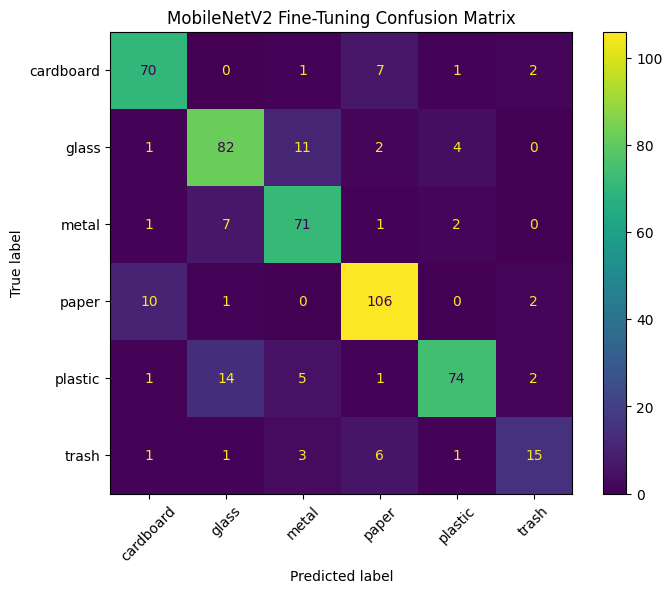

In [ ]:
#################################################
# CONFUSION MATRIX - MOBILENET FINE-TUNING
#################################################

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    preds_mobilenet
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(ax=ax)

plt.xticks(rotation=45)

plt.title("MobileNetV2 Fine-Tuning Confusion Matrix")

plt.show()

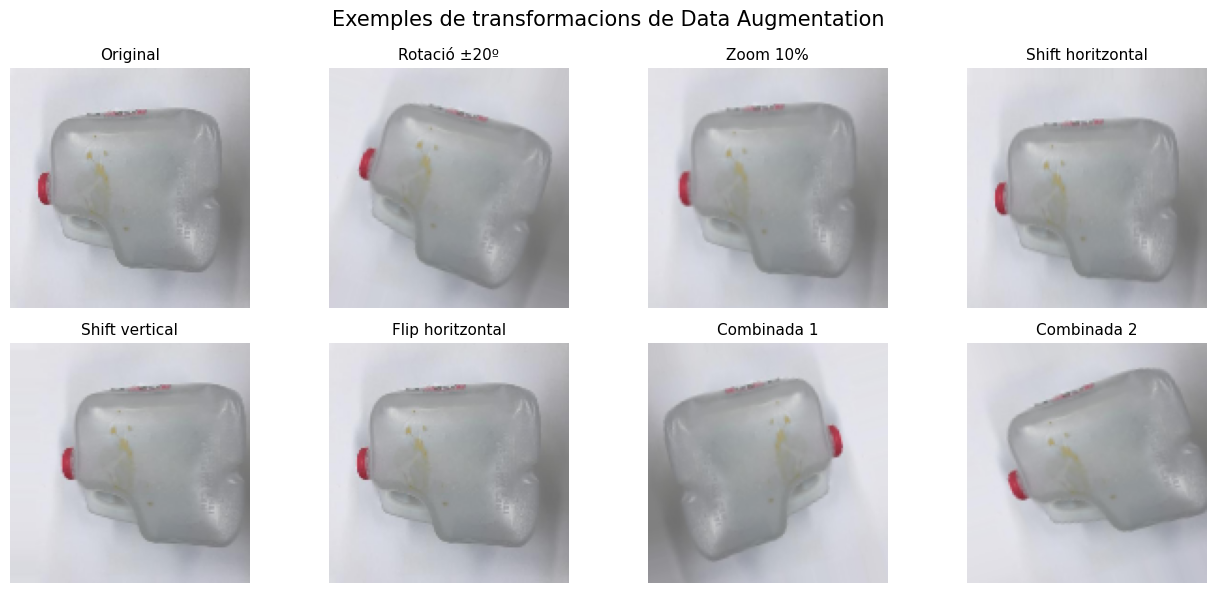

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Escollim una imatge d'exemple
idx = 9
img = X_train_img[idx]
img_batch = np.expand_dims(img, axis=0)

# Definim transformacions separades per visualitzar-les clarament
augmentations = {
    "Original": ImageDataGenerator(),

    "Rotació ±20º": ImageDataGenerator(
        rotation_range=20
    ),

    "Zoom 10%": ImageDataGenerator(
        zoom_range=0.1
    ),

    "Shift horitzontal": ImageDataGenerator(
        width_shift_range=0.1
    ),

    "Shift vertical": ImageDataGenerator(
        height_shift_range=0.1
    ),

    "Flip horitzontal": ImageDataGenerator(
        horizontal_flip=True
    ),

    "Combinada 1": ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    ),

    "Combinada 2": ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )
}

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
axes = axes.ravel()

for ax, (title, aug) in zip(axes, augmentations.items()):

    if title == "Original":
        aug_img = img
    else:
        aug_iter = aug.flow(
            img_batch,
            batch_size=1,
            shuffle=False
        )

        aug_img = next(aug_iter)[0]
        aug_img = np.clip(aug_img, 0, 1)

    ax.imshow(aug_img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Exemples de transformacions de Data Augmentation", fontsize=15)
plt.tight_layout()

plt.savefig("data_augmentation_transformacions.png", dpi=300, bbox_inches="tight")

plt.show()